# 6CS012 — Worksheet 1
## Image Processing with Python
### Introduction to Python Imaging Library (PIL)



**Student Name:** Aakansha Acharya

**Module Code:** 6CS012  
**Worksheet:** 1 — Image Processing  
**Topic:** PIL · NumPy · PCA Image Compression  


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMG_PATH = '/content/drive/MyDrive/AI ML/Aakanshaimage.jpeg'


## 2. Getting Started with Image Processing

### 2.1 Exercise 1 — Colour Image Operations


#### Task 1 — Read and Display the Image

Image shape : (1280, 960, 3)   (H x W x Channels)
Dtype       : uint8
Value range : 0 - 255


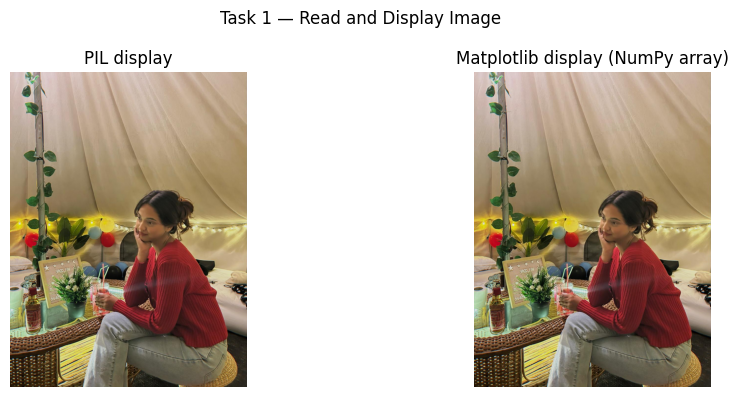

In [3]:
img_pil = Image.open(IMG_PATH).convert('RGB')
img     = np.array(img_pil)

print(f'Image shape : {img.shape}   (H x W x Channels)')
print(f'Dtype       : {img.dtype}')
print(f'Value range : {img.min()} - {img.max()}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_pil)
axes[0].set_title('PIL display')
axes[0].axis('off')
axes[1].imshow(img)
axes[1].set_title('Matplotlib display (NumPy array)')
axes[1].axis('off')
plt.suptitle('Task 1 — Read and Display Image')
plt.tight_layout()
plt.show()

#### Task 2 — Display Only the Top-Left Corner (100x100 pixels)

Cropped region shape: (100, 100, 3)


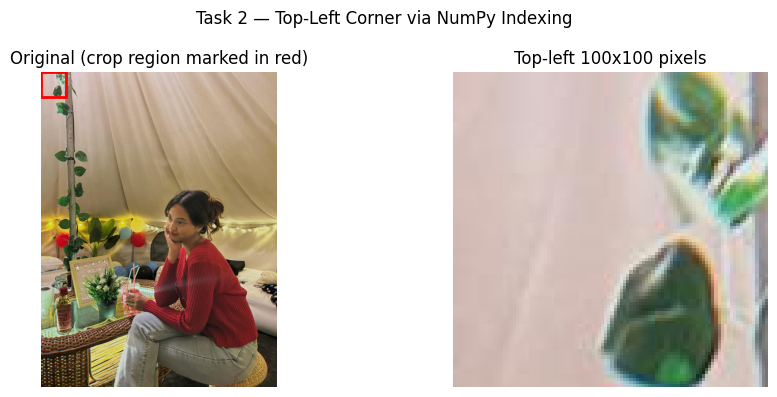

In [4]:
crop = img[:100, :100]
print(f'Cropped region shape: {crop.shape}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img)
rect = plt.Rectangle((0, 0), 100, 100, linewidth=2, edgecolor='red', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Original (crop region marked in red)')
axes[0].axis('off')
axes[1].imshow(crop)
axes[1].set_title('Top-left 100x100 pixels')
axes[1].axis('off')
plt.suptitle('Task 2 — Top-Left Corner via NumPy Indexing')
plt.tight_layout()
plt.show()

#### Task 3 — Show the Three Colour Channels (R, G, B)

Each channel is separated using NumPy array indexing and displayed with a matplotlib colourmap.

Note: The red, green, and blue backgrounds appear because of the `cmap` argument in `imshow()`. Each channel only contains intensity values (0–255), not colour. Matplotlib maps those intensities to the chosen colourmap for visual clarity. If displayed directly with PIL, each channel would appear in greyscale since PIL does not apply colourmaps automatically.

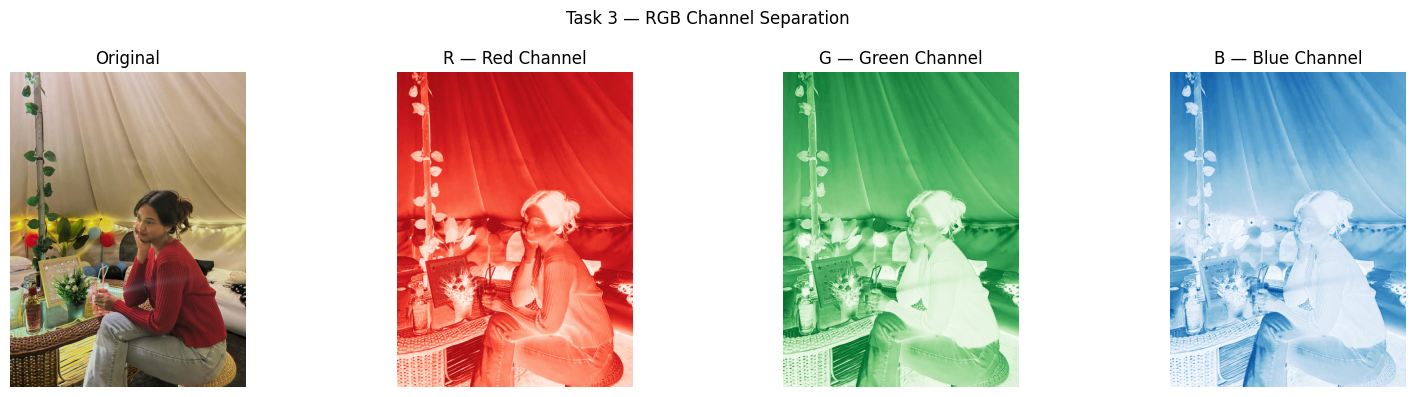

In [5]:
R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(R, cmap='Reds')
axes[1].set_title('R — Red Channel')
axes[1].axis('off')
axes[2].imshow(G, cmap='Greens')
axes[2].set_title('G — Green Channel')
axes[2].axis('off')
axes[3].imshow(B, cmap='Blues')
axes[3].set_title('B — Blue Channel')
axes[3].axis('off')
plt.suptitle('Task 3 — RGB Channel Separation')
plt.tight_layout()
plt.show()

#### Task 4 — Modify Top 100x100 Pixels to Value 210

Pixel at [50, 50] after modification: [210 210 210]  (should be [210, 210, 210])


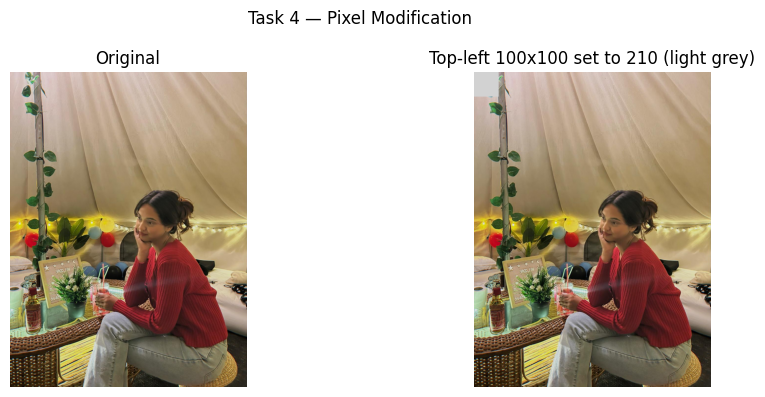

In [6]:
img_modified = img.copy()
img_modified[:100, :100] = 210

print(f'Pixel at [50, 50] after modification: {img_modified[50, 50]}  (should be [210, 210, 210])')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img)
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_modified)
axes[1].set_title('Top-left 100x100 set to 210 (light grey)')
axes[1].axis('off')
plt.suptitle('Task 4 — Pixel Modification')
plt.tight_layout()
plt.show()


### 2.2 Exercise 2 — Greyscale Image Operations

#### Task 1 — Load and Display a Greyscale Image

Greyscale shape : (1280, 960)  (H x W, single channel)
Dtype           : uint8
Value range     : 0 - 249


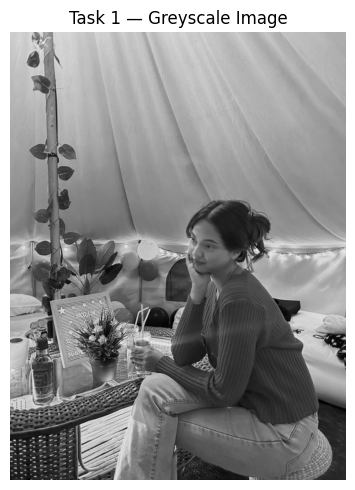

In [7]:
img_gray_pil = Image.open(IMG_PATH).convert('L')
img_gray     = np.array(img_gray_pil)

print(f'Greyscale shape : {img_gray.shape}  (H x W, single channel)')
print(f'Dtype           : {img_gray.dtype}')
print(f'Value range     : {img_gray.min()} - {img_gray.max()}')

plt.figure(figsize=(6, 5))
plt.imshow(img_gray, cmap='gray')
plt.title('Task 1 — Greyscale Image')
plt.axis('off')
plt.tight_layout()
plt.show()

#### Task 2 — Extract the Middle Section (150 pixels)

Centre crop shape: (150, 150)


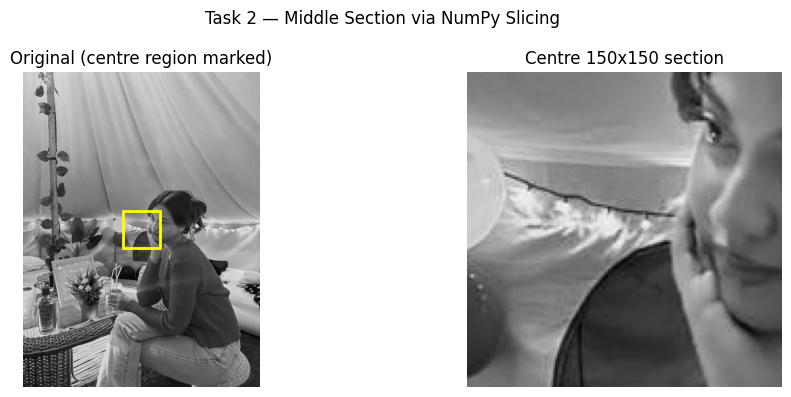

In [8]:
h, w = img_gray.shape
cy, cx = h // 2, w // 2
half = 75

r0, r1 = max(0, cy - half), min(h, cy + half)
c0, c1 = max(0, cx - half), min(w, cx + half)
middle_section = img_gray[r0:r1, c0:c1]

print(f'Centre crop shape: {middle_section.shape}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_gray, cmap='gray')
rect = plt.Rectangle((c0, r0), c1 - c0, r1 - r0, linewidth=2, edgecolor='yellow', facecolor='none')
axes[0].add_patch(rect)
axes[0].set_title('Original (centre region marked)')
axes[0].axis('off')
axes[1].imshow(middle_section, cmap='gray')
axes[1].set_title('Centre 150x150 section')
axes[1].axis('off')
plt.suptitle('Task 2 — Middle Section via NumPy Slicing')
plt.tight_layout()
plt.show()

#### Task 3 — Apply Threshold (Binary Image)

All pixel values below 100 are set to 0 (black) and all values above 100 are set to 255 (white), producing a binary image.

Threshold         : 100
Pixels set to 0   : 387,226
Pixels set to 255 : 841,574


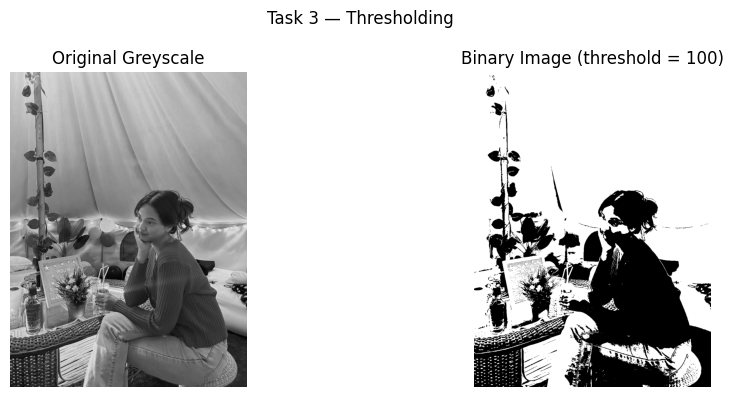

In [9]:
THRESHOLD = 100
img_binary = np.where(img_gray < THRESHOLD, 0, 255).astype(np.uint8)

print(f'Threshold         : {THRESHOLD}')
print(f'Pixels set to 0   : {(img_binary == 0).sum():,}')
print(f'Pixels set to 255 : {(img_binary == 255).sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original Greyscale')
axes[0].axis('off')
axes[1].imshow(img_binary, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Binary Image (threshold = {THRESHOLD})')
axes[1].axis('off')
plt.suptitle('Task 3 — Thresholding')
plt.tight_layout()
plt.show()

#### Task 4 — Rotate 90 Degrees Clockwise

Original shape : (1280, 960)
Rotated shape  : (960, 1280)


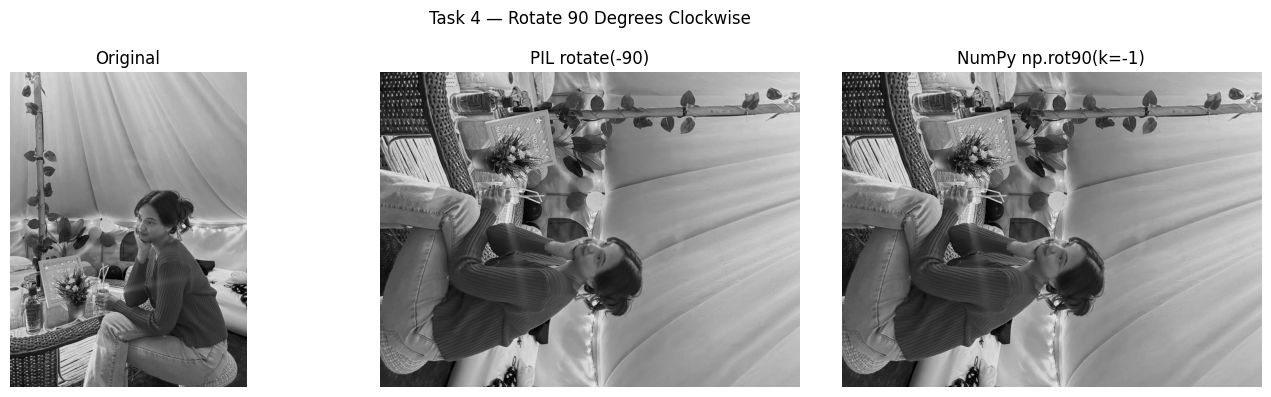

In [10]:
# PIL rotate is counter-clockwise by default, so -90 gives clockwise
img_rotated_pil = img_gray_pil.rotate(-90, expand=True)
img_rotated     = np.array(img_rotated_pil)

# NumPy alternative
img_rotated_np = np.rot90(img_gray, k=-1)

print(f'Original shape : {img_gray.shape}')
print(f'Rotated shape  : {img_rotated.shape}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
axes[1].imshow(img_rotated, cmap='gray')
axes[1].set_title('PIL rotate(-90)')
axes[1].axis('off')
axes[2].imshow(img_rotated_np, cmap='gray')
axes[2].set_title('NumPy np.rot90(k=-1)')
axes[2].axis('off')
plt.suptitle('Task 4 — Rotate 90 Degrees Clockwise')
plt.tight_layout()
plt.show()

#### Task 5 — Convert Greyscale to RGB

The greyscale values are replicated across all three channels (R = G = B = grey intensity) using `np.stack`.

Greyscale shape : (1280, 960)
RGB shape       : (1280, 960, 3)  (H x W x 3)
R == G == B?    : True


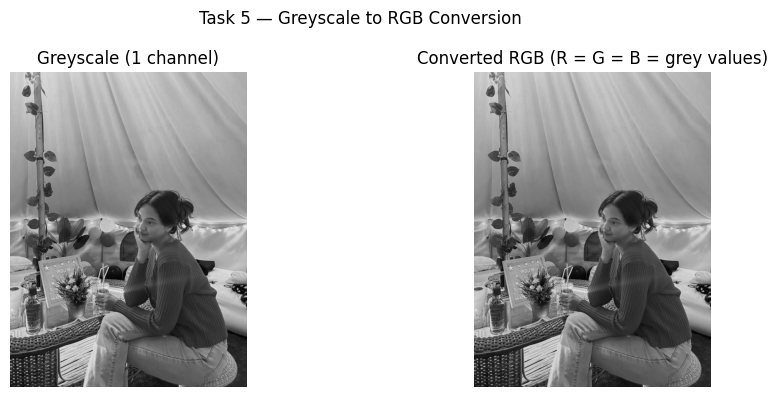

In [11]:
img_rgb_from_gray = np.stack([img_gray, img_gray, img_gray], axis=-1)

print(f'Greyscale shape : {img_gray.shape}')
print(f'RGB shape       : {img_rgb_from_gray.shape}  (H x W x 3)')
print(f'R == G == B?    : {np.array_equal(img_rgb_from_gray[:,:,0], img_rgb_from_gray[:,:,1])}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_gray, cmap='gray')
axes[0].set_title('Greyscale (1 channel)')
axes[0].axis('off')
axes[1].imshow(img_rgb_from_gray)
axes[1].set_title('Converted RGB (R = G = B = grey values)')
axes[1].axis('off')
plt.suptitle('Task 5 — Greyscale to RGB Conversion')
plt.tight_layout()
plt.show()


## 3. Image Compression and Decompression using PCA

PCA is built entirely from scratch using the explained variance method. No sklearn is used. All matrices are computed manually.



### Step 1 — Load, Prepare and Standardise Data

Image shape : (1280, 960)  (H x W)
Centred shape      : (1280, 960)
Standardised shape : (1280, 960)
Covariance matrix  : (960, 960)  (W x W)


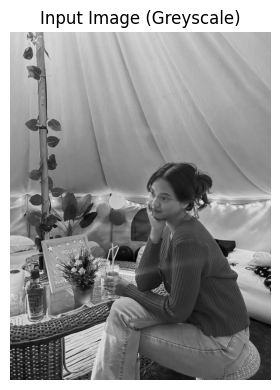

In [12]:
img_pca = np.array(Image.open(IMG_PATH).convert('L'), dtype=np.float64)
print(f'Image shape : {img_pca.shape}  (H x W)')

X = img_pca

# Centre: subtract column means
col_mean   = X.mean(axis=0)
X_centered = X - col_mean

# Standardise: divide by column std
col_std          = X.std(axis=0)
col_std[col_std == 0] = 1
X_std            = X_centered / col_std

# Covariance matrix (W x W)
n          = X_std.shape[0]
cov_matrix = (X_std.T @ X_std) / (n - 1)

print(f'Centred shape      : {X_centered.shape}')
print(f'Standardised shape : {X_std.shape}')
print(f'Covariance matrix  : {cov_matrix.shape}  (W x W)')

plt.figure(figsize=(5, 4))
plt.imshow(img_pca, cmap='gray')
plt.title('Input Image (Greyscale)')
plt.axis('off')
plt.tight_layout()
plt.show()

### Step 2 — Eigen Decomposition and Identifying Principal Components

Total eigenvalues    : 960
Top-5 eigenvalues    : [412.95 125.32  73.02  51.98  37.1 ]
Top-5 explained var. : [42.98 13.04  7.6   5.41  3.86] %

PCs needed for 80% variance : 9
PCs needed for 90% variance : 27
PCs needed for 95% variance : 60
PCs needed for 99% variance : 172


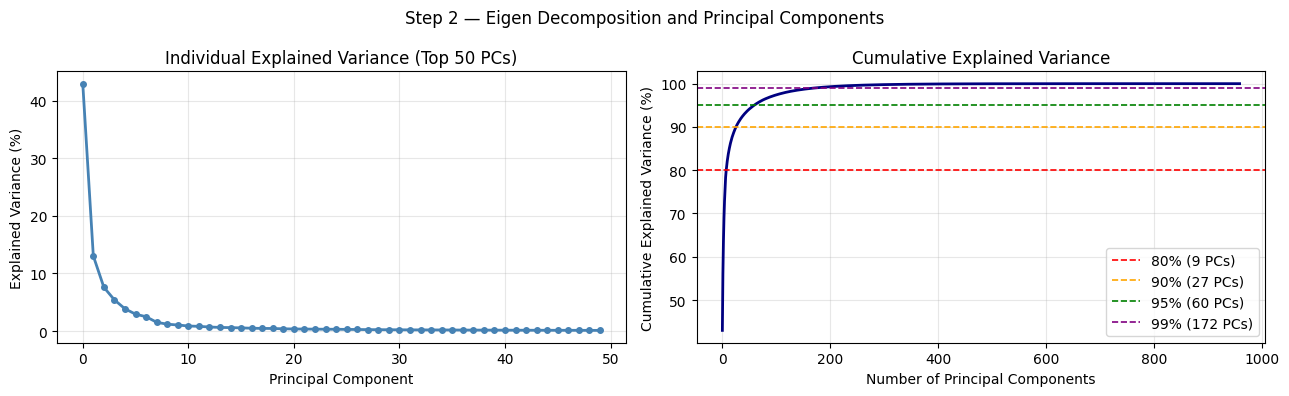

In [13]:
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)

# Sort descending
idx          = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Explained variance
total_var      = eigenvalues.sum()
explained_var  = eigenvalues / total_var
cumulative_var = np.cumsum(explained_var)

print(f'Total eigenvalues    : {len(eigenvalues)}')
print(f'Top-5 eigenvalues    : {eigenvalues[:5].round(2)}')
print(f'Top-5 explained var. : {(explained_var[:5]*100).round(2)} %')
print()
print(f'PCs needed for 80% variance : {np.searchsorted(cumulative_var, 0.80) + 1}')
print(f'PCs needed for 90% variance : {np.searchsorted(cumulative_var, 0.90) + 1}')
print(f'PCs needed for 95% variance : {np.searchsorted(cumulative_var, 0.95) + 1}')
print(f'PCs needed for 99% variance : {np.searchsorted(cumulative_var, 0.99) + 1}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(explained_var[:50] * 100, color='steelblue', linewidth=2, marker='o', markersize=4)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance (Top 50 PCs)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(cumulative_var * 100, color='navy', linewidth=2)
for threshold, color, label in [
    (0.80, 'red',    '80%'),
    (0.90, 'orange', '90%'),
    (0.95, 'green',  '95%'),
    (0.99, 'purple', '99%')
]:
    k = np.searchsorted(cumulative_var, threshold) + 1
    axes[1].axhline(threshold * 100, color=color, linestyle='--', linewidth=1.2, label=f'{label} ({k} PCs)')
axes[1].set_xlabel('Number of Principal Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Step 2 — Eigen Decomposition and Principal Components')
plt.tight_layout()
plt.show()

### Step 3 — Reconstruction and Experiments

Four different values of k are chosen, each corresponding to a different explained variance level. The image is projected onto the top-k eigenvectors (principal components) to get a lower-dimensional representation, then reconstructed back to pixel space.

In [ ]:
def pca_reconstruct(X_std, eigenvectors, col_mean, col_std, k):
    W_k     = eigenvectors[:, :k]       # (W, k)
    scores  = X_std @ W_k               # (H, k) — compressed representation
    X_recon = scores @ W_k.T            # (H, W) — back to original dimensions
    X_recon = X_recon * col_std + col_mean
    X_recon = np.clip(X_recon, 0, 255).astype(np.uint8)
    return X_recon

k =    3  |  Explained variance = 63.63%  |  Compression ratio = 320.0x
k =    9  |  Explained variance = 81.03%  |  Compression ratio = 106.7x
k =   27  |  Explained variance = 90.21%  |  Compression ratio = 35.6x
k =  172  |  Explained variance = 99.00%  |  Compression ratio = 5.6x


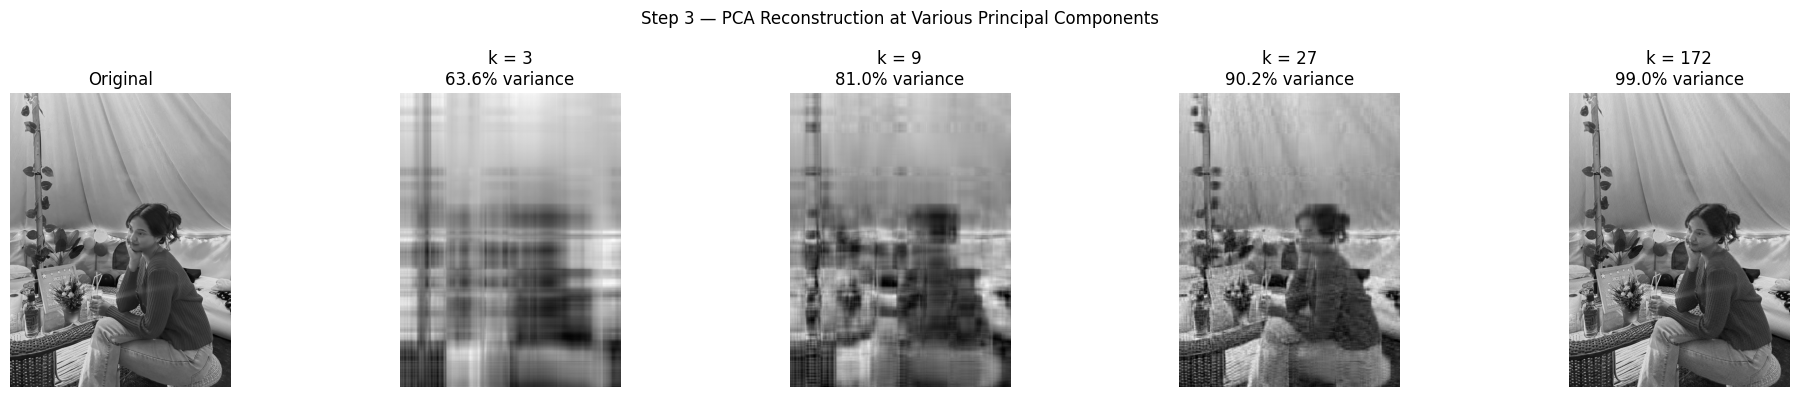

In [15]:
def pca_reconstruct(X_std, eigenvectors, col_mean, col_std, k):
    W_k     = eigenvectors[:, :k]       # (W, k)
    scores  = X_std @ W_k               # (H, k) — compressed representation
    X_recon = scores @ W_k.T            # (H, W) — back to original dimensions
    X_recon = X_recon * col_std + col_mean
    X_recon = np.clip(X_recon, 0, 255).astype(np.uint8)
    return X_recon

k_values = [
    np.searchsorted(cumulative_var, 0.60) + 1,
    np.searchsorted(cumulative_var, 0.80) + 1,
    np.searchsorted(cumulative_var, 0.90) + 1,
    np.searchsorted(cumulative_var, 0.99) + 1,
]

reconstructions = []
for k in k_values:
    recon = pca_reconstruct(X_std, eigenvectors, col_mean, col_std, k)
    ev    = cumulative_var[k - 1] * 100
    reconstructions.append((k, ev, recon))
    print(f'k = {k:4d}  |  Explained variance = {ev:.2f}%  |  Compression ratio = {img_pca.shape[1]/k:.1f}x')

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
axes[0].imshow(img_pca, cmap='gray')
axes[0].set_title('Original')
axes[0].axis('off')
for ax, (k, ev, recon) in zip(axes[1:], reconstructions):
    ax.imshow(recon, cmap='gray')
    ax.set_title(f'k = {k}\n{ev:.1f}% variance')
    ax.axis('off')
plt.suptitle('Step 3 — PCA Reconstruction at Various Principal Components')
plt.tight_layout()
plt.show()

### Evaluation — MSE and PSNR

MSE (Mean Squared Error) measures reconstruction error. PSNR (Peak Signal-to-Noise Ratio) measures quality in decibels — higher is better. Values above 30 dB are generally considered visually acceptable.

In [16]:
original_f64 = img_pca.astype(np.float64)

print(f'{"k":>6}  {"Expl. Var":>12}  {"MSE":>10}  {"PSNR (dB)":>12}  {"Compression":>12}')
print('-' * 60)

for k, ev, recon in reconstructions:
    mse  = np.mean((original_f64 - recon.astype(np.float64)) ** 2)
    psnr = 10 * np.log10((255 ** 2) / mse) if mse > 0 else float('inf')
    comp = img_pca.shape[1] / k
    print(f'{k:>6}  {ev:>11.2f}%  {mse:>10.2f}  {psnr:>11.2f} dB  {comp:>10.1f}x')

     k     Expl. Var         MSE     PSNR (dB)   Compression
------------------------------------------------------------
     3        63.63%      878.23        18.69 dB       320.0x
     9        81.03%      467.89        21.43 dB       106.7x
    27        90.21%      241.01        24.31 dB        35.6x
   172        99.00%       25.23        34.11 dB         5.6x
